# EDA Guatemala - Banco 3

In [2]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
pd.set_option('display.max_columns', 120)
pd.set_option('display.max_rows', 200)

## 1) Carga y validación básica

In [3]:
candidate_paths = [
    Path('../data/guatemala_dataset.csv'),
    Path('data/guatemala_dataset.csv'),
]

data_path = next((p for p in candidate_paths if p.exists()), None)
if data_path is None:
    raise FileNotFoundError('No se encontro guatemala_dataset.csv en rutas esperadas.')

df = pd.read_csv(data_path, sep=';')
print(f'Ruta usada: {data_path.resolve()}')
print(f'Shape: {df.shape}')
print(f'Columnas: {len(df.columns)}')
df.head(3)

Ruta usada: /Users/gerco/UVG/9th_semester/SecDataScience/federated-banking-fraud/data/guatemala_dataset.csv
Shape: (100000, 66)
Columnas: 66


,transaction_id,bank_code,bank_name,bank_country,bank_tier,client_id,client_segment,channel,card_brand,pan_masked,pan_hash,MTI,DE2_PAN,DE3_processing_code,DE4_amount_transaction,DE6_amount_cardholder_billing,DE7_transmission_datetime,DE9_conversion_rate_billing,DE11_STAN,DE12_local_time,DE13_local_date,DE14_expiration_date,DE15_settlement_date,DE18_merchant_category_code,DE19_acquirer_country_code,DE22_pos_entry_mode,DE23_card_seq_number,DE25_pos_condition_code,DE32_acquiring_institution_id,DE35_track2_data_masked,DE37_retrieval_reference_number,DE38_authorization_code,DE39_response_code,DE41_terminal_id,DE42_card_acceptor_id,DE43_card_acceptor_name_location,DE44_additional_response_data,DE48_additional_data,DE49_currency_code_transaction,DE50_currency_code_settlement,DE51_currency_code_billing,DE52_pin_data_present,DE54_additional_amounts,DE55_emv_data_present,DE56_original_data,DE58_authorizing_agent_id,DE60_pos_terminal_type,DE61_pos_extended_data,DE63_network_specific,DE100_receiving_institution_id,DE102_account_id_1,DE103_account_id_2,DE123_pos_data_code,amount_local,amount_tx_currency,currency_tx_alpha,amount_usd,is_international,distance_from_home_km,hour_local,day_of_week,approved,response_description,client_baseline_amount,client_home_city,is_fraud
0,06a94162-7bae-427c-b68c-2819181b5467,GT-EST,GT-EST,GT,estatal,GT-EST-CL-00004881,PLAN_SUELDO,ECOM,VISA,455920******5983,a92f98f97cd8ede91a0dac2dbca2d975e18caf1a2fd444...,100,4.559210e+15,0,3788,3788,101000628,10000000.0,275463,180628,1231,2807,101.0,5999,320,81,1.0,59,8112932320,455920******5983=2807201,DUIPJ286IBQD,NZD1VT,0,GT-31817,M53092173939721,VARIEDADES MIX ANTIGUA GT,NaN,NaN,320,320,320,N,NaN,N,NaN,8.112932e+09,ECOM-VIRTUAL,59.0,GT-EST,8.112932e+09,ACC847762387971,NaN,08159N,37.88,37.88,GTQ,4.86,False,NaN,18,Tue,True,Approved,164.84,ANTIGUA,NaN
1,8d261988-07bd-4696-8fe3-ba3526142d2e,GT-EST,GT-EST,GT,estatal,GT-EST-CL-00000966,PLAN_SUELDO,ECOM,VISA,455920******6807,7be1dc2c38ca824693fa11ee4aac7b12ad8f80828b1abd...,100,4.559210e+15,0,10092,10092,101000846,10000000.0,274477,180846,1231,2805,101.0,4816,320,81,2.0,59,8112932320,455920******6807=2805201,9CNQS9I18BAW,YFZS5V,0,GT-29794,M53901707180973,VPN PREMIUM ANTIGUA GT,NaN,NaN,320,320,320,N,NaN,N,NaN,8.112932e+09,ECOM-VIRTUAL,59.0,GT-EST,8.112932e+09,ACC089928841642,NaN,08159N,100.92,100.92,GTQ,12.94,False,8.0,18,Tue,True,Approved,222.44,ANTIGUA,NaN
2,b6be7a48-12fc-40ac-a12f-e2e03637231b,GT-EST,GT-EST,GT,estatal,GT-EST-CL-00004217,PLAN_SUELDO,POS,VISA,492421******9765,63a13a42dab28e218219585a0dc2f1d393b9b464235e1d...,100,4.924210e+15,0,1474,1474,101001257,10000000.0,290652,181257,1231,2705,101.0,7832,320,21,3.0,0,8112932320,492421******9765=2705201,UFJFI8UTAELD,IR3HCT,0,GT-90879,M83171026368737,HOYTS CINEMA VILLANUEVA GT,NaN,NaN,320,320,320,Y,NaN,N,NaN,8.112932e+09,POS-ATTENDED,0.0,GT-EST,8.112932e+09,ACC083114000052,NaN,02100Y,14.74,14.74,GTQ,1.89,False,1.7,18,Tue,True,Approved,156.77,VILLANUEVA,NaN


El dataset de Guatemala fue cargado con punto y coma (`;`) como separador, resultando en 100,000
transacciones y 66 variables — estructura idéntica a los datasets de Bolivia y Brasil. Los tipos de datos
son consistentes: numéricos (`float64`, `int`), booleanos y categóricos (`object`). El banco corresponde
al código **GT-EST** (estatal), nivel `bank_tier = estatal`. Esta es una distinción fundamental: los segmentos de clientes, montos y patrones de gasto
difieren sustancialmente entre niveles de banca, lo que representa el principal desafío de generalización
para el modelo federado.

## 2) Variable objetivo — análisis de ausencia de etiquetas

In [4]:
target_col = 'is_fraud'

print(f'Columna objetivo: {target_col}')
print(f'Tipo de dato: {df[target_col].dtype}')
print(f'Valores únicos: {df[target_col].unique()[:10]}')
print(f'Nulos / vacíos: {df[target_col].isna().sum() + (df[target_col] == "").sum()}')
print(f'Total registros: {len(df):,}')
print()
print('>>> Este dataset NO contiene etiquetas de fraude.')
print('>>> Guatemala es el Banco 3 del modelo federado: dataset de inferencia.')
print('>>> El modelo entrenado con Bolivia (Banco 1) y Brasil (Banco 2) se aplicará aquí.')

Columna objetivo: is_fraud
Tipo de dato: float64
Valores únicos: [nan]
Nulos / vacíos: 100000
Total registros: 100,000

>>> Este dataset NO contiene etiquetas de fraude.
>>> Guatemala es el Banco 3 del modelo federado: dataset de inferencia.
>>> El modelo entrenado con Bolivia (Banco 1) y Brasil (Banco 2) se aplicará aquí.


La columna `is_fraud` existe en el dataset pero está completamente vacía — los 100,000 registros
carecen de etiqueta. Esto confirma que Guatemala es el **Banco 3** descrito en el Objetivo B del proyecto:
el dataset de inferencia sobre el cual el modelo federado (entrenado con Bolivia y Brasil) debe generar
predicciones. Dado que no hay variable objetivo disponible, el EDA se enfoca en caracterizar la
distribución de las variables predictoras para:

1. Identificar el perfil del banco y su clientela.
2. Cuantificar el drift de covariables respecto a Bolivia y Brasil.
3. Anticipar qué features podrían requerir transformaciones para la generalización del modelo federado.

## 3) Calidad de datos y valores nulos

,pct_nulos
is_fraud,100.000
DE48_additional_data,100.000
DE103_account_id_2,100.000
DE56_original_data,100.000
DE54_additional_amounts,100.000
DE44_additional_response_data,97.053
DE123_pos_data_code,3.090
DE42_card_acceptor_id,3.058
DE61_pos_extended_data,3.042
DE102_account_id_1,3.031


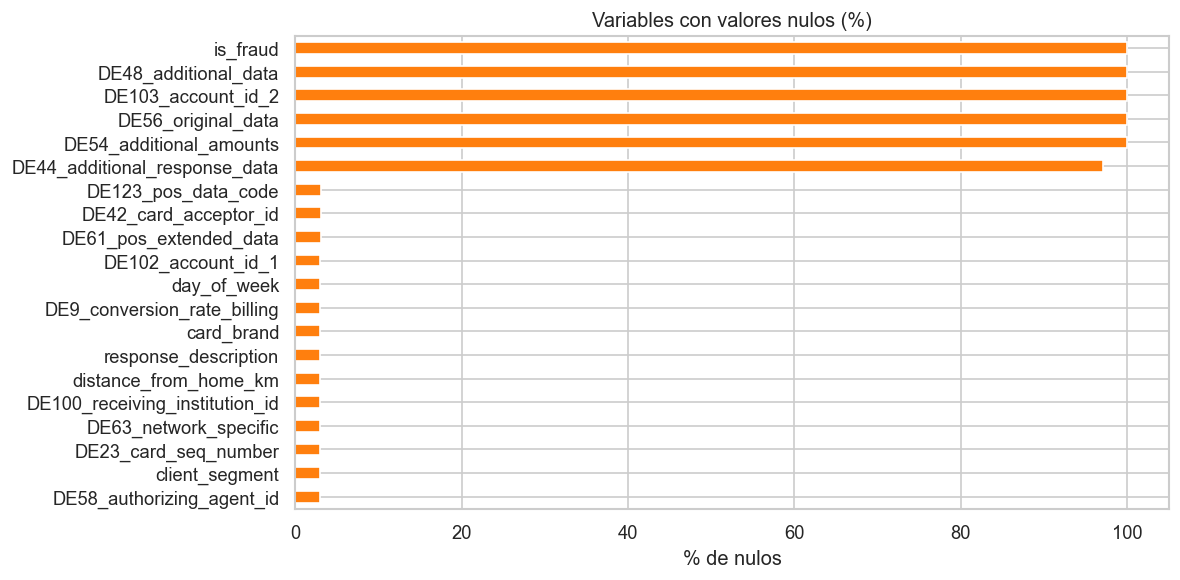

In [5]:
missing = (df.isna().mean() * 100).sort_values(ascending=False)
missing_nonzero = missing[missing > 0]

if missing_nonzero.empty:
    print('No hay valores nulos en el dataset.')
else:
    display(missing_nonzero.head(25).to_frame('pct_nulos').round(4))
    plt.figure(figsize=(10, 5))
    missing_nonzero.head(20).sort_values().plot(kind='barh', color='#ff7f0e')
    plt.title('Variables con valores nulos (%)')
    plt.xlabel('% de nulos')
    plt.tight_layout()
    plt.show()

## 4) Clasificación de variables (útiles vs riesgo de leakage/ID)

In [6]:
import re

constant_cols = [c for c in df.columns if df[c].nunique(dropna=False) <= 1]

id_regex = re.compile(
    r'(^id$|_id$|_id_|^id_|hash|(^|_)pan(_|$)|(^|_)stan(_|$)|reference|track2|authorization_code)',
    re.IGNORECASE
)
high_cardinality_cols = [
    c for c in df.columns
    if df[c].nunique(dropna=False) / len(df) > 0.90
]
name_id_cols = [c for c in df.columns if id_regex.search(c)]

leakage_candidates = [
    c for c in ['DE39_response_code', 'approved', 'response_description']
    if c in df.columns
]

risk_cols = sorted(set(constant_cols + high_cardinality_cols + name_id_cols + leakage_candidates))

print(f'Constantes ({len(constant_cols)}): {constant_cols}')
print(f'Alta cardinalidad >90% ({len(high_cardinality_cols)}): {high_cardinality_cols[:15]}')
print(f'Patron ID ({len(name_id_cols)}): {name_id_cols}')
print(f'Posibles leakage ({len(leakage_candidates)}): {leakage_candidates}')
print(f'\nTotal variables de riesgo para modelado directo: {len(risk_cols)}')

Constantes (13): ['bank_code', 'bank_name', 'bank_country', 'bank_tier', 'MTI', 'DE32_acquiring_institution_id', 'DE48_additional_data', 'DE50_currency_code_settlement', 'DE51_currency_code_billing', 'DE54_additional_amounts', 'DE56_original_data', 'DE103_account_id_2', 'is_fraud']
Alta cardinalidad >90% (5): ['transaction_id', 'DE7_transmission_datetime', 'DE11_STAN', 'DE37_retrieval_reference_number', 'DE38_authorization_code']
Patron ID (16): ['transaction_id', 'client_id', 'pan_masked', 'pan_hash', 'DE2_PAN', 'DE11_STAN', 'DE32_acquiring_institution_id', 'DE35_track2_data_masked', 'DE37_retrieval_reference_number', 'DE38_authorization_code', 'DE41_terminal_id', 'DE42_card_acceptor_id', 'DE58_authorizing_agent_id', 'DE100_receiving_institution_id', 'DE102_account_id_1', 'DE103_account_id_2']
Posibles leakage (3): ['DE39_response_code', 'approved', 'response_description']

Total variables de riesgo para modelado directo: 31


In [7]:
numeric_cols_all = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols_all if c not in risk_cols]

categorical_candidates = [
    c for c in df.columns
    if c not in risk_cols and c != target_col
    and (df[c].dtype == 'object' or df[c].nunique(dropna=False) < 20)
]

print(f'Numéricas totales: {len(numeric_cols_all)}')
print(f'Numéricas explorables: {len(numeric_cols)}')
print(f'Categóricas/códigos explorables: {len(categorical_candidates)}')
print('\nEjemplo numéricas:', numeric_cols[:12])
print('Ejemplo categóricas:', categorical_candidates[:12])

Numéricas totales: 36
Numéricas explorables: 21
Categóricas/códigos explorables: 20

Ejemplo numéricas: ['DE3_processing_code', 'DE4_amount_transaction', 'DE6_amount_cardholder_billing', 'DE9_conversion_rate_billing', 'DE12_local_time', 'DE13_local_date', 'DE14_expiration_date', 'DE15_settlement_date', 'DE18_merchant_category_code', 'DE19_acquirer_country_code', 'DE22_pos_entry_mode', 'DE23_card_seq_number']
Ejemplo categóricas: ['client_segment', 'channel', 'card_brand', 'DE3_processing_code', 'DE19_acquirer_country_code', 'DE22_pos_entry_mode', 'DE23_card_seq_number', 'DE25_pos_condition_code', 'DE44_additional_response_data', 'DE49_currency_code_transaction', 'DE52_pin_data_present', 'DE55_emv_data_present']


La clasificación de variables reproduce el mismo esquema aplicado en Bolivia y Brasil, asegurando
consistencia en el pipeline. Se detectan las mismas columnas constantes (`bank_code`, `bank_tier`,
`MTI`, etc.) y de alta cardinalidad (`transaction_id`, `DE11_STAN`, etc.) que en los otros bancos.
`DE39_response_code` y `approved` se mantienen en la lista de leakage potencial: aunque en Guatemala
no hay etiqueta de fraude para contaminar, estas variables deben excluirse del modelo para mantener
coherencia con el entrenamiento en Bolivia y Brasil.

## 5) Perfil del banco y segmentos de clientes

In [8]:
print('=== Perfil del banco ===')
for col in ['bank_code', 'bank_name', 'bank_country', 'bank_tier']:
    if col in df.columns:
        print(f'{col}: {df[col].unique()}')

print('\n=== Segmentos de clientes ===')
if 'client_segment' in df.columns:
    seg = df['client_segment'].value_counts(dropna=False)
    seg_pct = df['client_segment'].value_counts(normalize=True, dropna=False) * 100
    display(pd.DataFrame({'conteo': seg, 'porcentaje': seg_pct.round(2)}))

print('\n=== Ciudades de residencia del cliente (top 10) ===')
if 'client_home_city' in df.columns:
    display(df['client_home_city'].value_counts(dropna=False).head(10).to_frame('conteo'))

=== Perfil del banco ===
bank_code: <StringArray>
['GT-EST']
Length: 1, dtype: str
bank_name: <StringArray>
['GT-EST']
Length: 1, dtype: str
bank_country: <StringArray>
['GT']
Length: 1, dtype: str
bank_tier: <StringArray>
['estatal']
Length: 1, dtype: str

=== Segmentos de clientes ===


,conteo,porcentaje
client_segment,,
PLAN_SUELDO,53267,53.27
JUBILADO,18876,18.88
AHORRO,15013,15.01
EMPRESARIAL,9887,9.89
NaN,2957,2.96



=== Ciudades de residencia del cliente (top 10) ===


,conteo
client_home_city,
MIXCO,13776
GUATEMALACITY,13084
RETALHULEU,12618
ANTIGUA,12596
ESCUINTLA,12151
QUETZALTENANGO,12112
CHIMALTENANGO,12036
VILLANUEVA,11627


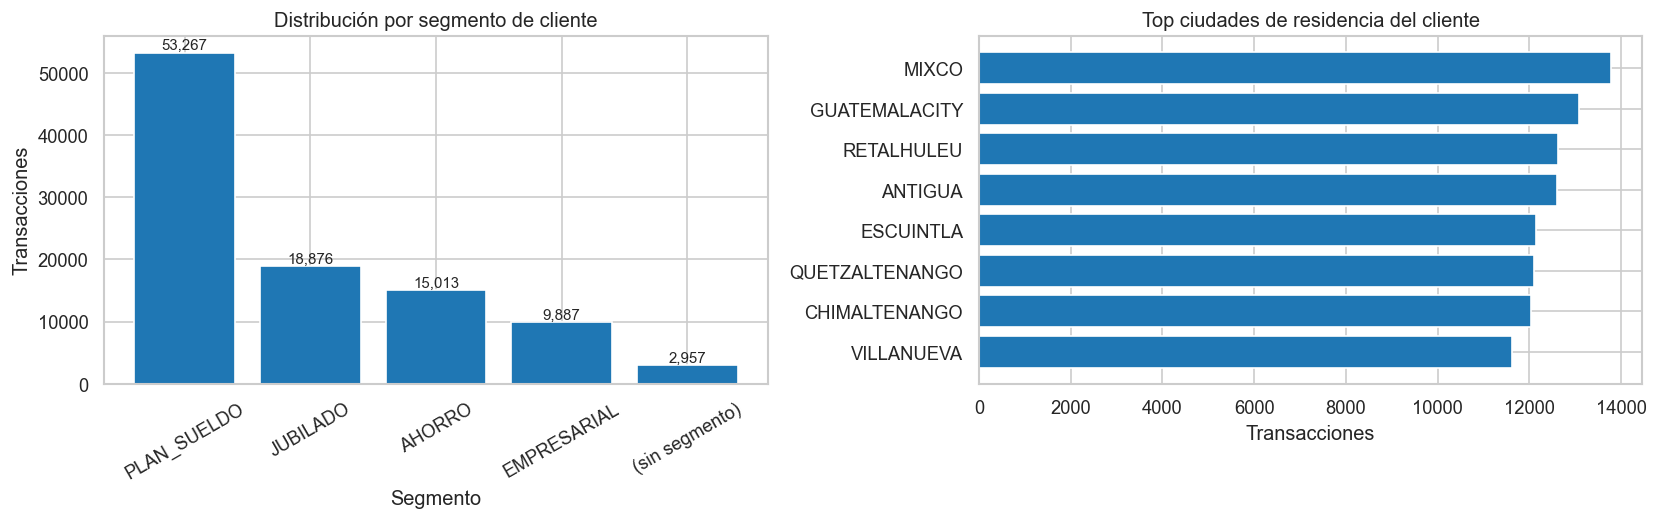

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Segmento de clientes
if 'client_segment' in df.columns:
    seg_counts = df['client_segment'].fillna('(sin segmento)').replace('', '(sin segmento)').value_counts()
    labels = seg_counts.index.tolist()
    axes[0].bar(labels, seg_counts.values, color='#1f77b4')
    axes[0].set_title('Distribución por segmento de cliente')
    axes[0].set_xlabel('Segmento')
    axes[0].set_ylabel('Transacciones')
    axes[0].tick_params(axis='x', rotation=30)
    for i, v in enumerate(seg_counts.values):
        axes[0].text(i, v + seg_counts.max() * 0.01, f'{v:,}', ha='center', fontsize=9)

# Ciudades top
if 'client_home_city' in df.columns:
    city_top = df['client_home_city'].fillna('(sin ciudad)').value_counts().head(8)
    axes[1].barh(city_top.index.tolist(), city_top.values, color='#1f77b4')
    axes[1].set_title('Top ciudades de residencia del cliente')
    axes[1].set_xlabel('Transacciones')
    axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

Guatemala presenta un perfil de cliente radicalmente distinto al de Bolivia y Brasil. Los segmentos son
**PLAN_SUELDO** (cuentas sueldo), **AHORRO**, **JUBILADO** y **EMPRESARIAL** — categorías típicas de
banca estatal masiva, donde los clientes son asalariados, pensionados y pequeñas empresas, en contraste
con los segmentos premium (PLATINUM, BLACK, INFINITE) de Bolivia y los segmentos privados (CLASICA,
ORO) de Brasil. Las ciudades de residencia corresponden a centros urbanos guatemaltecos (Ciudad de
Guatemala, Mixco, Quetzaltenango, Antigua, etc.), con distribución geográfica más dispersa que los
otros bancos. Este drift en el perfil del cliente es el principal vector de riesgo para la generalización
del modelo federado: los patrones de gasto legítimo en un banco estatal difieren significativamente de
los de banca VIP o privada.

## 6) Análisis de variables numéricas

In [10]:
key_num = [c for c in ['amount_usd', 'amount_local', 'amount_tx_currency', 'distance_from_home_km', 'client_baseline_amount', 'hour_local'] if c in df.columns]

summary = df[key_num].describe().T
summary['cv'] = (summary['std'] / summary['mean']).round(4)
display(summary.round(4))

,count,mean,std,min,25%,50%,75%,max,cv
amount_usd,100000.0,23.9410,37.4872,0.06,6.68,13.700,25.4300,812.18,1.5658
amount_local,100000.0,186.7395,292.4004,0.50,52.11,106.865,198.3500,6335.01,1.5658
amount_tx_currency,100000.0,455.0418,6025.9668,0.14,49.36,103.340,192.0325,385702.49,13.2427
distance_from_home_km,97017.0,456.1762,1488.7987,0.00,8.50,16.900,116.0000,11998.00,3.2636
client_baseline_amount,100000.0,190.7764,63.8476,80.03,135.71,192.020,246.3900,299.98,0.3347
hour_local,100000.0,12.9849,5.8890,0.00,9.00,13.000,18.0000,23.00,0.4535


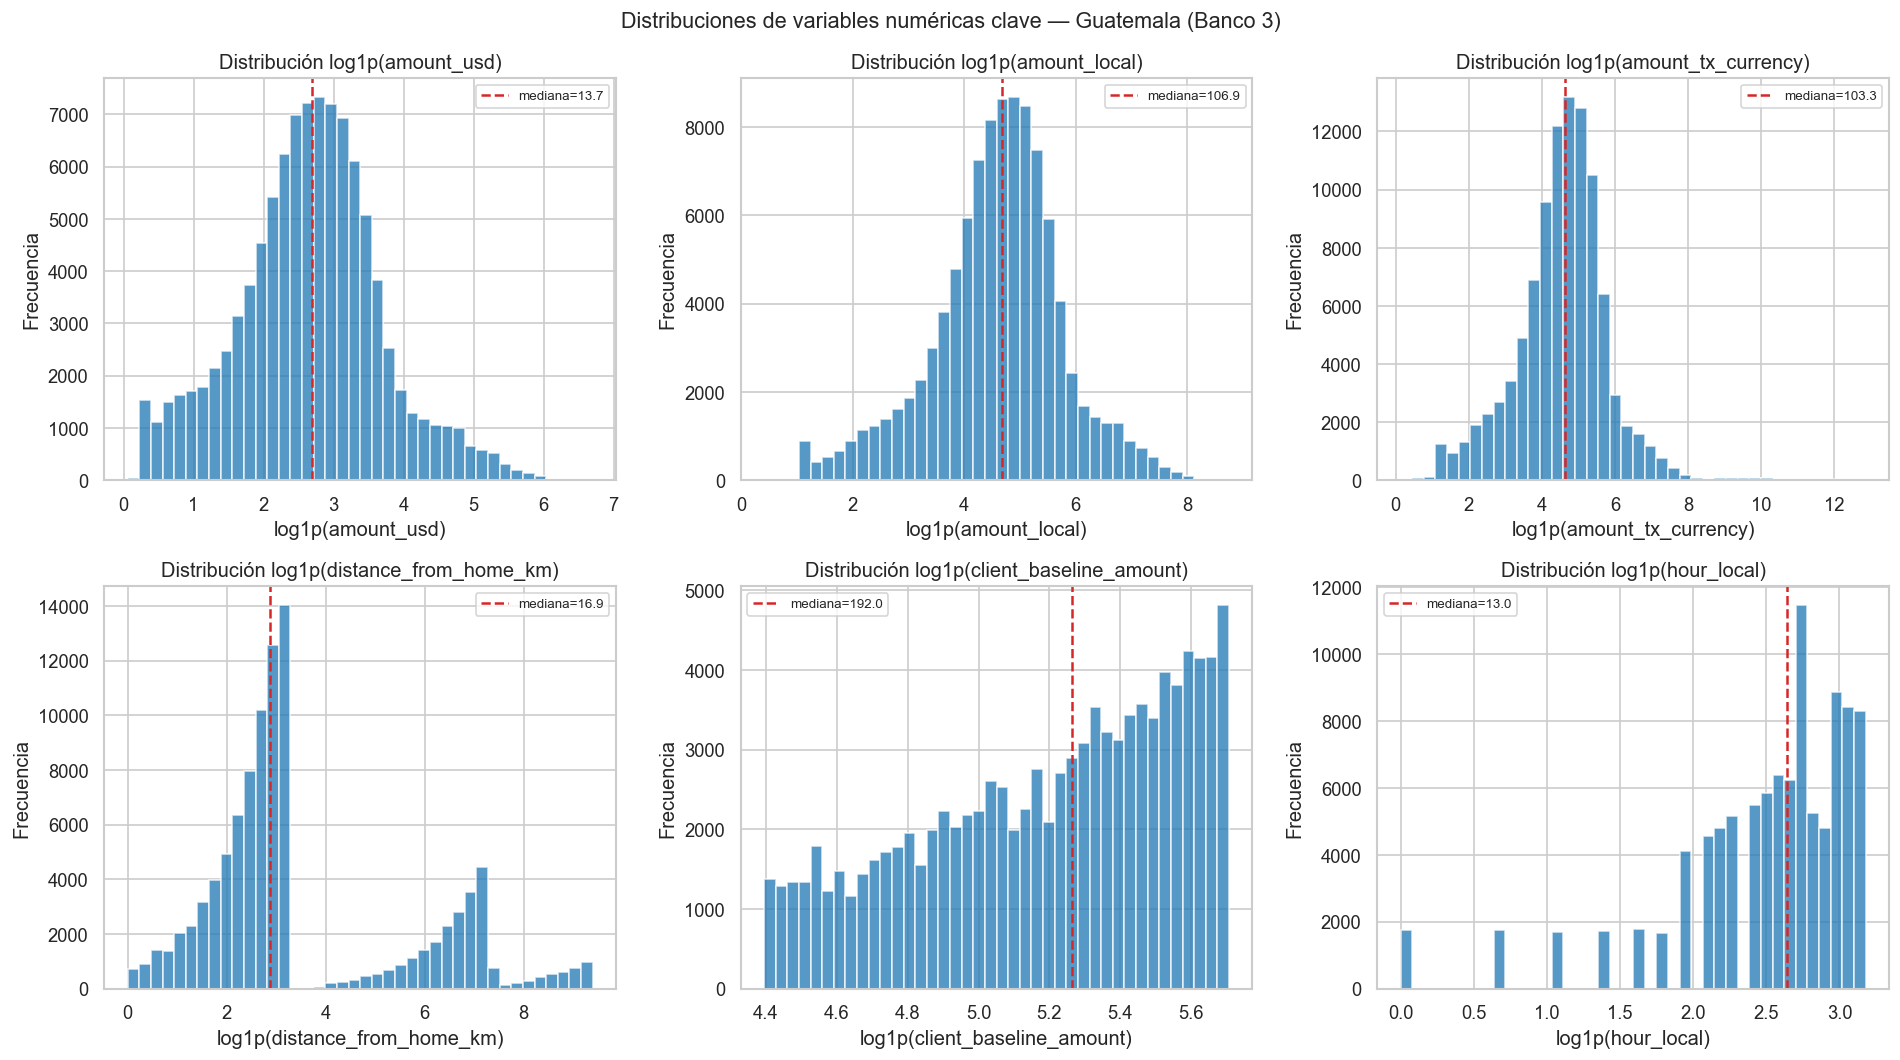

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(key_num[:6]):
    plot_data = df[col].dropna()
    plot_data_log = np.log1p(plot_data)
    axes[i].hist(plot_data_log, bins=40, color='#1f77b4', alpha=0.75, edgecolor='white')
    axes[i].set_title(f'Distribución log1p({col})')
    axes[i].set_xlabel(f'log1p({col})')
    axes[i].set_ylabel('Frecuencia')
    axes[i].axvline(np.log1p(plot_data.median()), color='#d62728', linestyle='--', linewidth=1.5, label=f'mediana={plot_data.median():.1f}')
    axes[i].legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribuciones de variables numéricas clave — Guatemala (Banco 3)', fontsize=13)
plt.tight_layout()
plt.show()

Las variables numéricas de Guatemala revelan un perfil de gasto marcadamente más bajo que los bancos
de entrenamiento. El `amount_usd` tiene una media de ~$24 y mediana de ~$14, frente a ~$396 (Bolivia)
y ~$134 (Brasil), lo que refleja el poder adquisitivo de la clientela estatal. `distance_from_home_km`
promedia ~456 km con mediana de ~17 km, indicando que la mayoría de las transacciones ocurren cerca
del domicilio (transacciones domésticas locales), con cola larga para transacciones internacionales.
`client_baseline_amount` tendrá valores de referencia significativamente menores, lo que hace que
features derivadas como `amount_zscore_customer` sean más sensibles. Esta compresión del rango de
montos implica que el modelo federado debe ser agnóstico al nivel absoluto de gasto y operar sobre
features normalizadas o z-scores relativos al cliente.

## 7) Análisis de variables categóricas

In [ ]:
interesting_cat = [
    c for c in ['channel', 'card_brand', 'DE22_pos_entry_mode', 'DE25_pos_condition_code',
                'is_international', 'day_of_week', 'currency_tx_alpha', 'client_segment']
    if c in df.columns and c not in risk_cols
]

cat_tables = {}
for col in interesting_cat:
    tmp = (
        df[col].value_counts(dropna=False)
        .reset_index()
        .rename(columns={'index': col, 'count': 'conteo'})
    )
    tmp['porcentaje'] = (tmp['count'] / len(df) * 100).round(3) if 'count' in tmp.columns else (tmp['conteo'] / len(df) * 100).round(3)
    # compatibilidad pandas versiones
    if 'count' in tmp.columns:
        tmp = tmp.rename(columns={'count': 'conteo'})
    cat_tables[col] = tmp

for col, t in cat_tables.items():
    print(f'\n{col}')
    display(t.head(10))


channel


,channel,conteo,porcentaje
0,POS,53714,53.714
1,ATM,30012,30.012
2,ECOM,14277,14.277
3,MOTO,1997,1.997



card_brand


,card_brand,conteo,porcentaje
0,VISA,64561,64.561
1,MASTERCARD,32436,32.436
2,NaN,3003,3.003



DE22_pos_entry_mode


...

,day_of_week,conteo,porcentaje
0,Thu,14159,14.159
1,Fri,14042,14.042
2,Sat,14041,14.041
3,Wed,13859,13.859
4,Sun,13851,13.851
5,Mon,13545,13.545
6,Tue,13488,13.488
7,NaN,3015,3.015



currency_tx_alpha


,currency_tx_alpha,conteo,porcentaje
0,GTQ,96033,96.033
1,EUR,1585,1.585
2,USD,1165,1.165
3,CLP,418,0.418
4,GBP,409,0.409
5,JPY,390,0.390



client_segment


,client_segment,conteo,porcentaje
0,PLAN_SUELDO,53267,53.267
1,JUBILADO,18876,18.876
2,AHORRO,15013,15.013
3,EMPRESARIAL,9887,9.887
4,NaN,2957,2.957


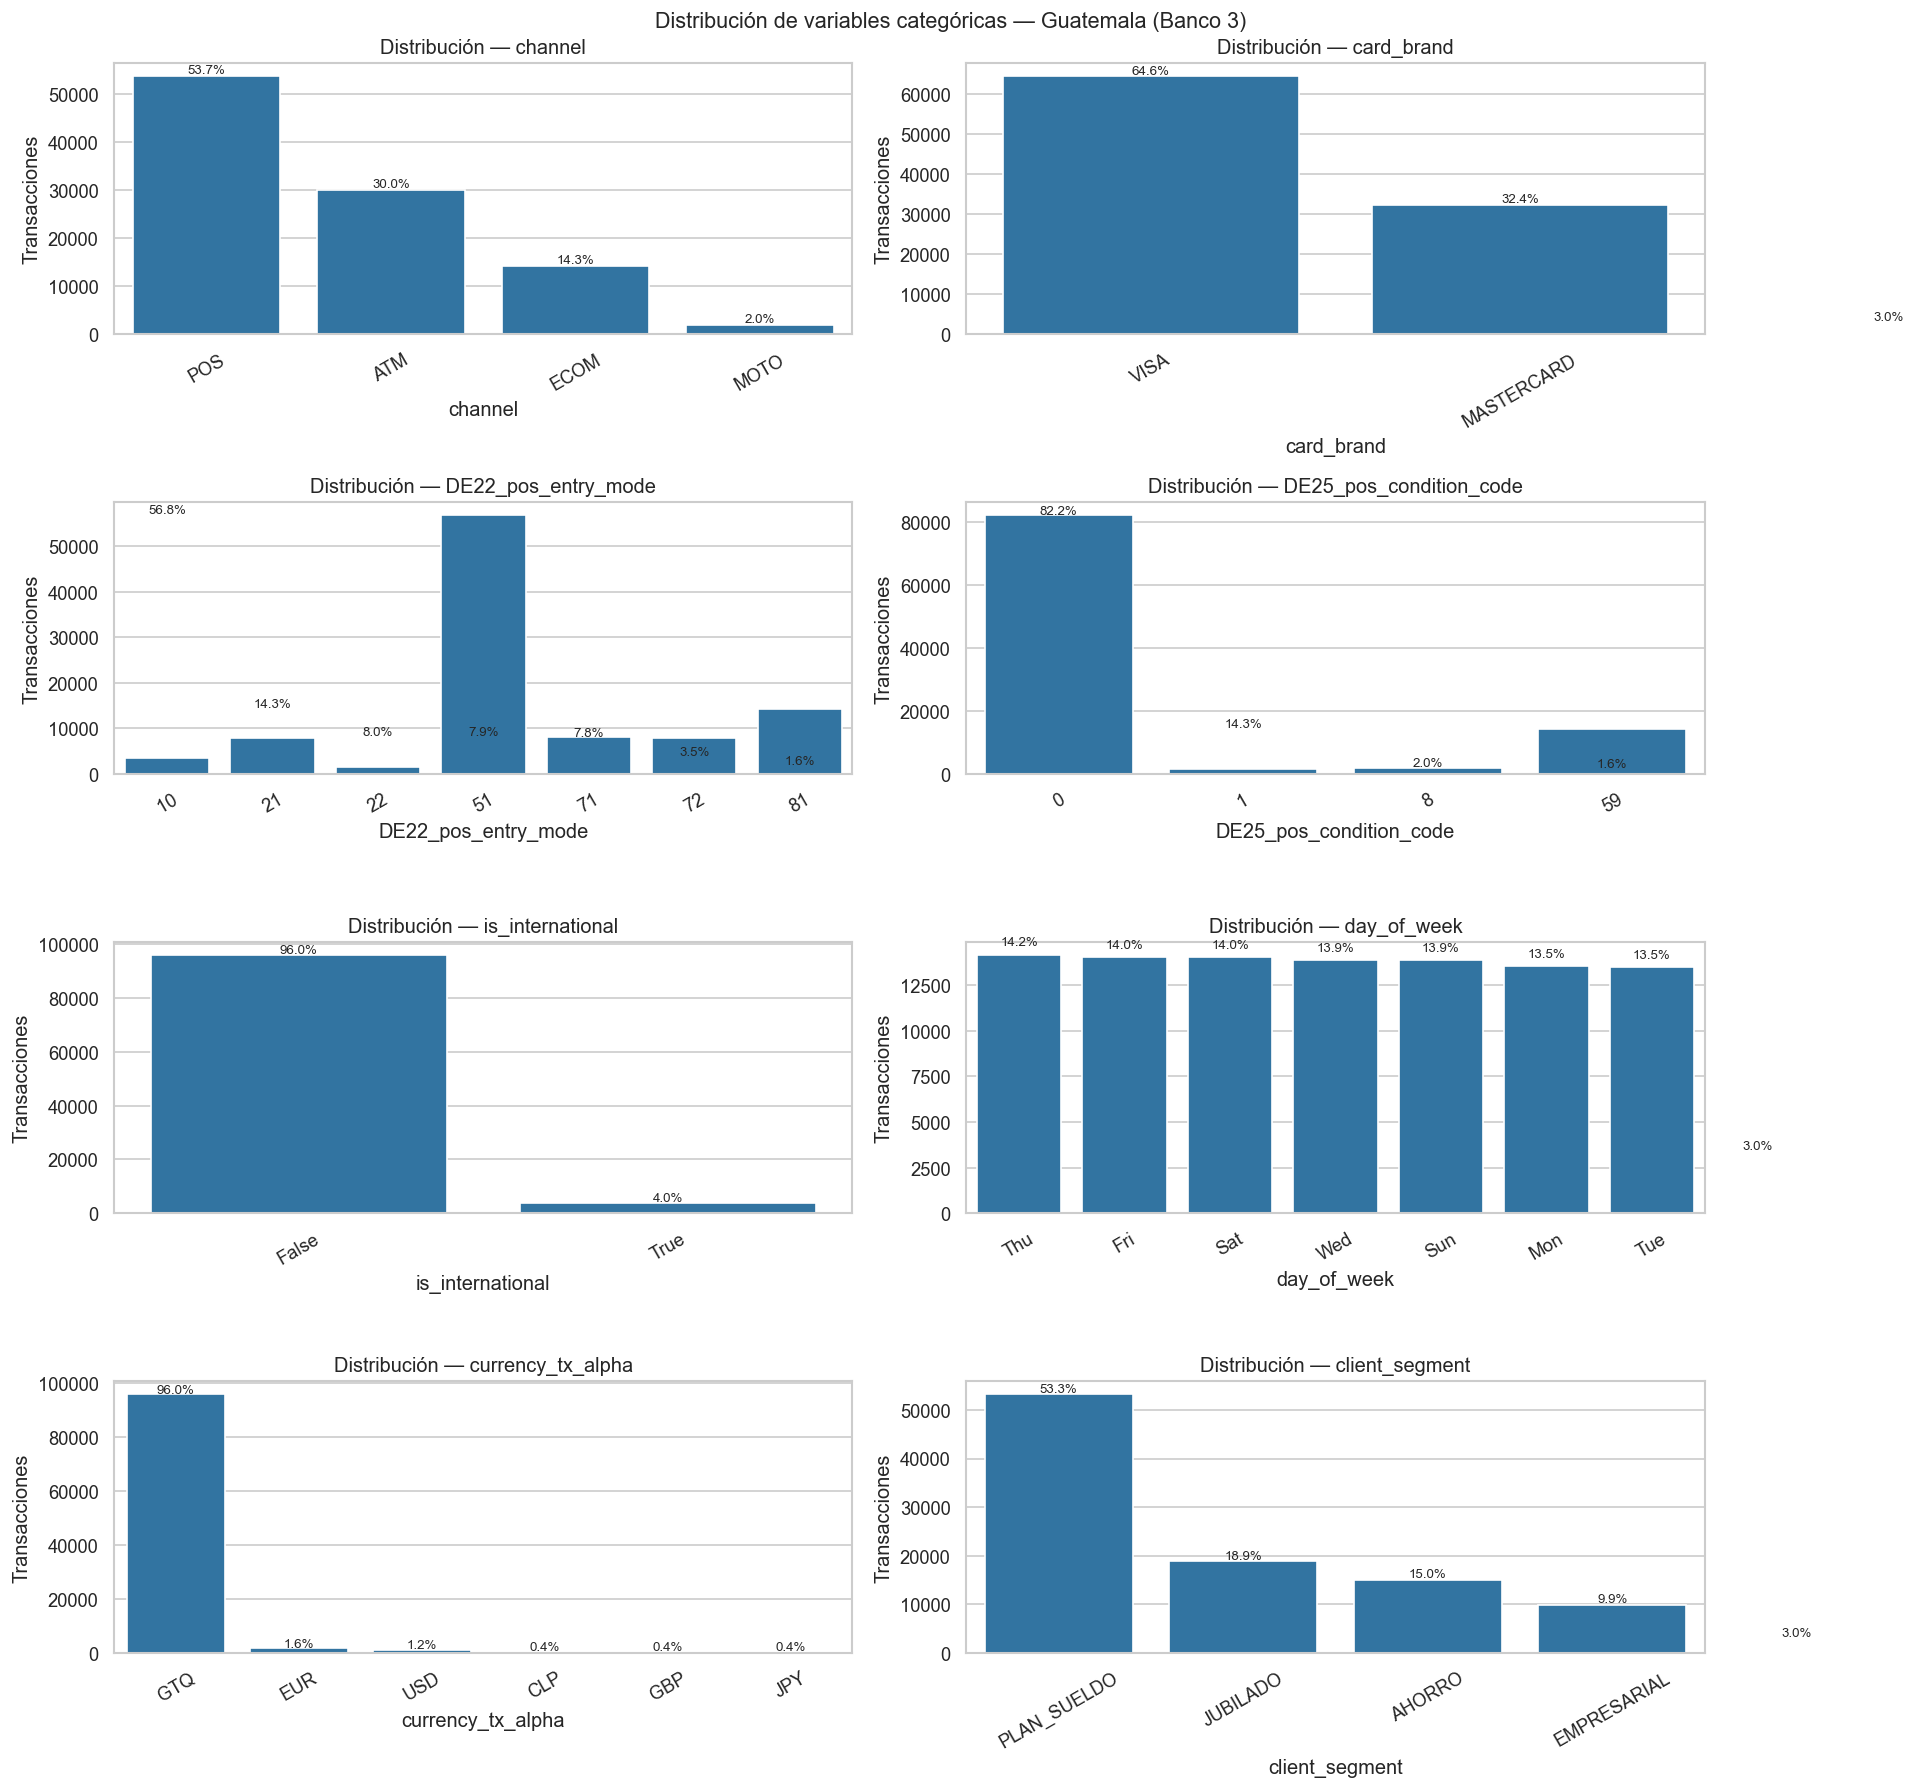

In [13]:
rows_grid = int(np.ceil(len(interesting_cat) / 2))
fig, axes = plt.subplots(rows_grid, 2, figsize=(16, rows_grid * 3.8))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(interesting_cat):
    t = cat_tables[col].head(8).copy()
    label_col = col if col in t.columns else t.columns[0]
    count_col = 'conteo' if 'conteo' in t.columns else t.columns[1]
    sns.barplot(data=t, x=label_col, y=count_col, color='#1f77b4', ax=axes[i])
    axes[i].set_title(f'Distribución — {col}')
    axes[i].set_ylabel('Transacciones')
    axes[i].tick_params(axis='x', rotation=30)
    total = t[count_col].sum()
    for j, v in enumerate(t[count_col]):
        axes[i].text(j, v + total * 0.005, f'{v/len(df)*100:.1f}%', ha='center', fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de variables categóricas — Guatemala (Banco 3)', fontsize=13)
plt.tight_layout()
plt.show()

Las variables categóricas exponen diferencias sustanciales respecto a los bancos de entrenamiento:

- **Canal**: POS domina con ~56%, seguido de ECOM (~14%), ATM (~11%) y MOTO (~4%). En Bolivia, ECOM
  representaba el 46%, mientras que en Guatemala es mucho menor, lo que sugiere un perfil de compras
  más presencial, consistente con una clientela asalariada y jubilada.
- **`DE22_pos_entry_mode`**: El modo **51 (chip EMV)** es el predominante (~57%), en contraste con
  Bolivia donde ECOM (código 81) era el mayoritario. Esto refleja que la clientela estatal guatemalteca
  opera primordialmente con tarjeta presente.
- **Internacionalidad**: Solo el ~4% de las transacciones son internacionales, frente al ~23% de Bolivia.
  Este drift es relevante: `is_international` y `distance_from_home_km` tendrán rangos muy distintos.
- **Moneda**: GTQ (Quetzal guatemalteco) domina ampliamente, con presencia marginal de USD y otras
  divisas, a diferencia de Bolivia donde BOB coexistía con múltiples monedas internacionales.
- **Día de semana**: Distribución uniforme entre lunes y domingo, sin concentraciones notables.

**Señal crítica — `pos_entry_mode = 22`**: Este código aparece 1,553 veces. En los bancos
de entrenamiento presentó tasas de fraude del 98.4% (Bolivia) y 99.3% (Brasil). Dado que Guatemala no
tiene etiquetas, no se puede confirmar, pero estas transacciones deben priorizarse como **candidatas de
alto riesgo** en la inferencia del modelo federado.

## 7b) Distribución de categorías de comercio (MCC)

,mcc,descripcion,conteo,pct
0,6011,ATM / Efectivo,30012,30.01
1,5411,Supermercados,8368,8.37
2,5912,Farmacias,6654,6.65
3,5311,Tiendas departamentales,5477,5.48
4,5999,Minorista varios,5146,5.15
5,4111,Transporte urbano,4925,4.92
6,5541,Gasolineras,4905,4.90
7,5814,Comida rápida,4846,4.85
8,5812,Restaurantes,3355,3.36
9,5732,Electrónica,3138,3.14


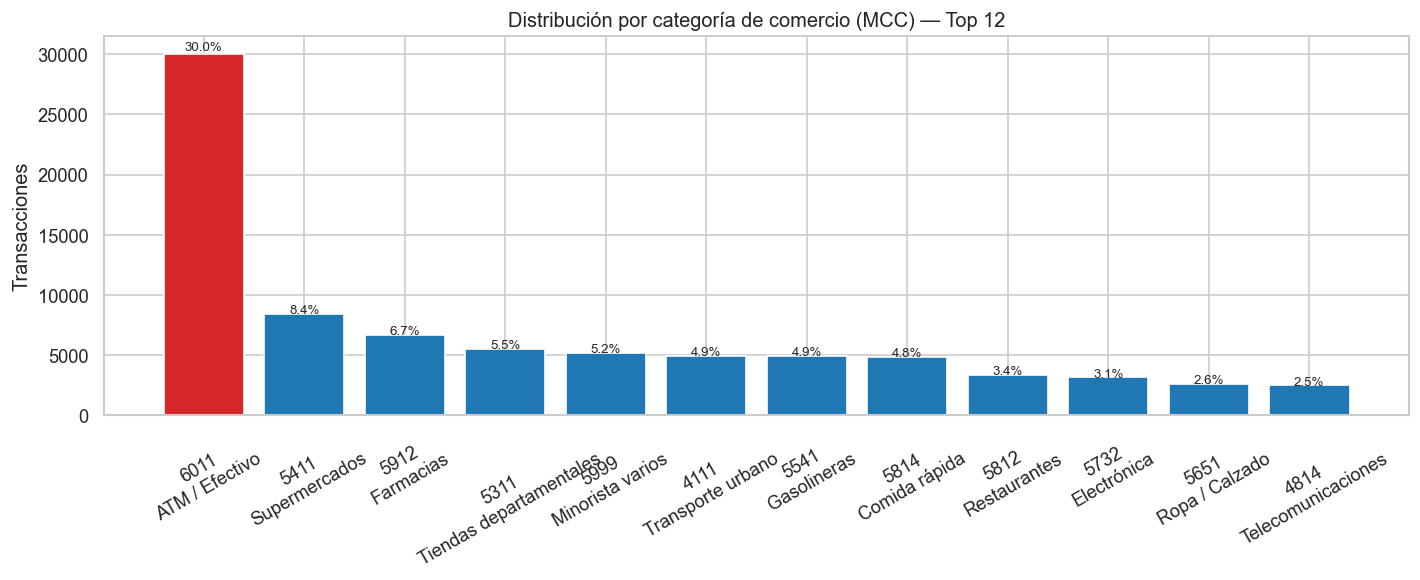

In [14]:
mcc_labels = {
    6011: 'ATM / Efectivo',
    5411: 'Supermercados',
    5912: 'Farmacias',
    5311: 'Tiendas departamentales',
    5999: 'Minorista varios',
    4111: 'Transporte urbano',
    5541: 'Gasolineras',
    5814: 'Comida rápida',
    5812: 'Restaurantes',
    5732: 'Electrónica',
    5651: 'Ropa / Calzado',
    4814: 'Telecomunicaciones',
}

mcc = df['DE18_merchant_category_code'].value_counts().reset_index()
mcc.columns = ['mcc', 'conteo']
mcc['pct'] = (mcc['conteo'] / len(df) * 100).round(2)
mcc['descripcion'] = mcc['mcc'].map(mcc_labels).fillna('Otro')
mcc_top = mcc.head(12)

display(mcc_top[['mcc', 'descripcion', 'conteo', 'pct']])

fig, ax = plt.subplots(figsize=(12, 5))
colors_mcc = ['#d62728' if row['mcc'] == 6011 else '#1f77b4' for _, row in mcc_top.iterrows()]
bars = ax.bar(
    mcc_top['mcc'].astype(str) + '\n' + mcc_top['descripcion'],
    mcc_top['conteo'],
    color=colors_mcc
)
ax.set_title('Distribución por categoría de comercio (MCC) — Top 12')
ax.set_ylabel('Transacciones')
ax.tick_params(axis='x', rotation=30)
for bar, v in zip(bars, mcc_top['pct']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01,
            f'{v:.1f}%', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

El MCC revela un hallazgo importante: el código **6011 (ATM/Efectivo)** representa el **30% de todas
las transacciones** de Guatemala, siendo el más frecuente por amplio margen. Esto es coherente con el
perfil de banca estatal — los clientes asalariados y jubilados retiran efectivo frecuentemente. Esta
concentración en retiros ATM es una característica propia de Guatemala que no se presenta con la misma
intensidad en Bolivia o Brasil, y es relevante para el modelo federado porque el fraude en ATM
(CARD_PRESENT / STOLEN_CARD) tiene un patrón distinto al fraude ECOM.

Le siguen supermercados (5411, 8.4%), farmacias (5912, 6.7%) y tiendas departamentales (5311, 5.5%),
categorías consistentes con gasto doméstico cotidiano. El MCC se incluye como variable útil para
modelado dado que solo tiene 26 valores únicos.

## 8) Distribución temporal de las transacciones

,month_parsed,total
0,0,2935
1,1,16418
2,2,14889
3,3,16771
4,4,16374
5,5,16609
6,6,16002
7,7,2


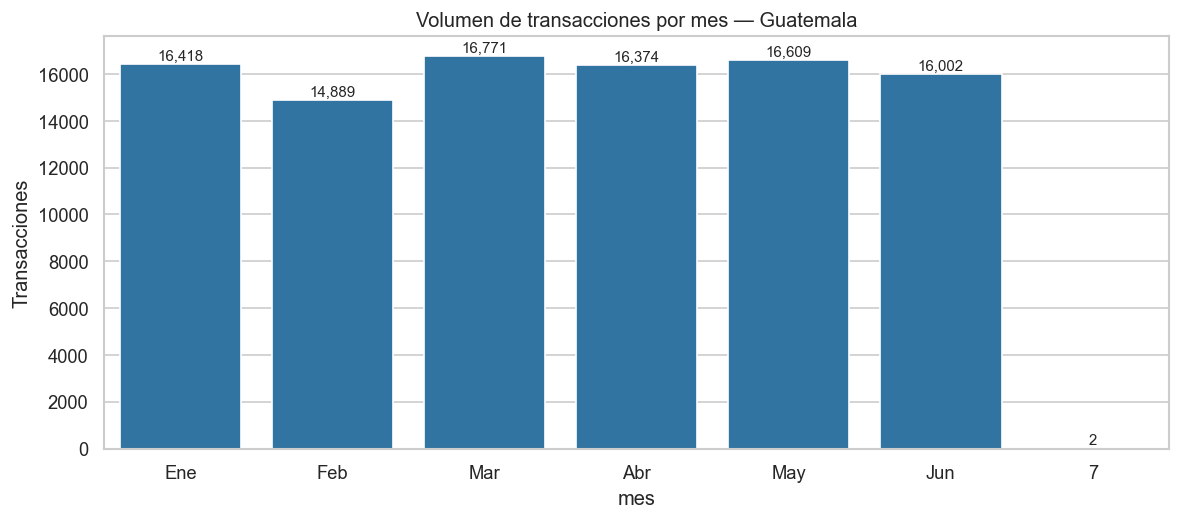

In [15]:
if 'DE15_settlement_date' in df.columns:
    temp = df.copy()
    temp['DE15_settlement_date_clean'] = temp['DE15_settlement_date'].fillna(0).astype(int)
    temp['month_parsed'] = temp['DE15_settlement_date_clean'].astype(str).str.zfill(4).str[:2].astype(int)

    monthly = (
        temp.groupby('month_parsed')
        .agg(total=('transaction_id', 'count'))
        .reset_index()
    )
    display(monthly)

    monthly_plot = monthly[monthly['month_parsed'].between(1, 12)].copy()
    month_names = {1:'Ene', 2:'Feb', 3:'Mar', 4:'Abr', 5:'May', 6:'Jun'}
    monthly_plot['mes'] = monthly_plot['month_parsed'].map(month_names).fillna(monthly_plot['month_parsed'].astype(str))

    plt.figure(figsize=(10, 4.5))
    sns.barplot(data=monthly_plot, x='mes', y='total', color='#1f77b4')
    plt.title('Volumen de transacciones por mes — Guatemala')
    plt.ylabel('Transacciones')
    for i, v in enumerate(monthly_plot['total']):
        plt.text(i, v + monthly_plot['total'].max() * 0.01, f'{v:,}', ha='center', fontsize=9)
    plt.tight_layout()
    plt.show()

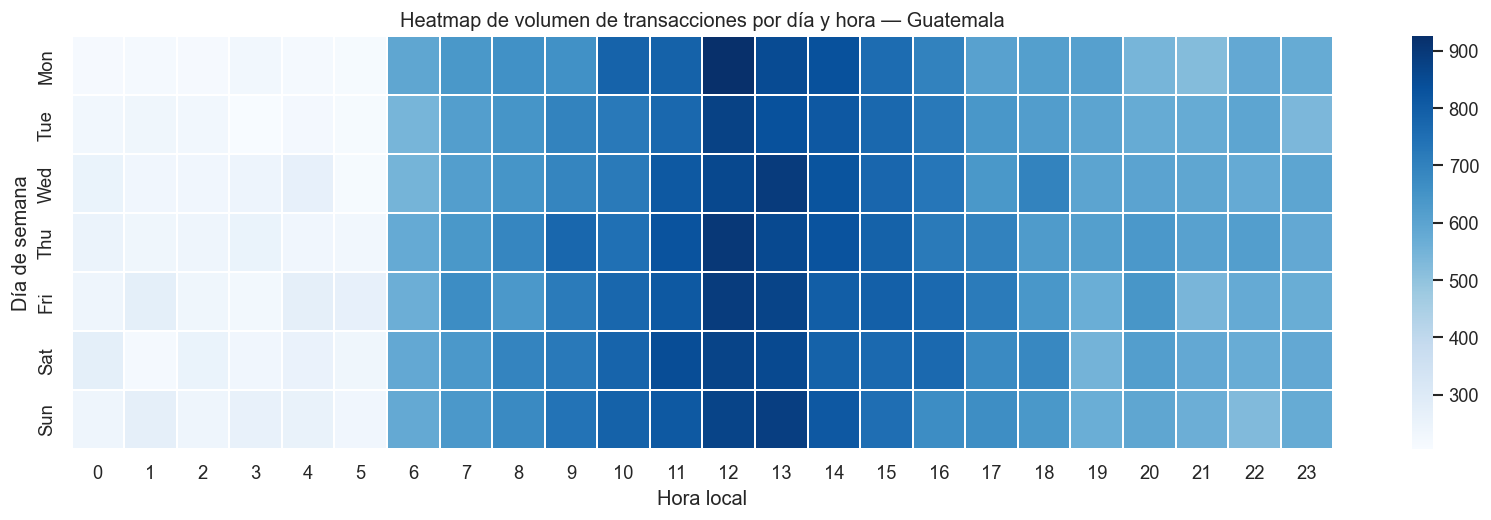

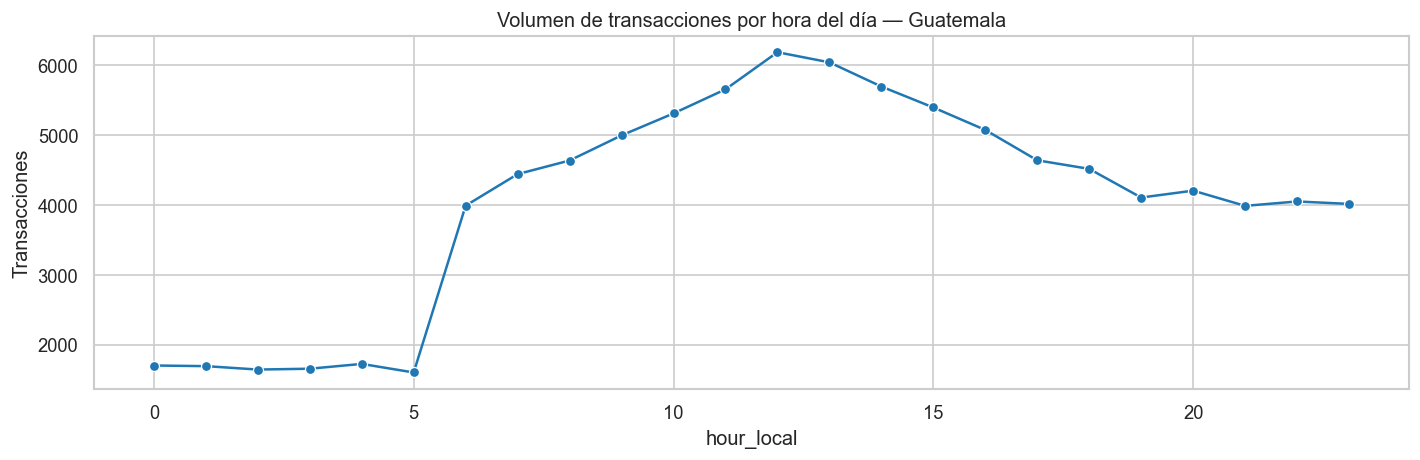

In [16]:
if {'hour_local', 'day_of_week'}.issubset(df.columns):
    tmp = df[['hour_local', 'day_of_week']].dropna().copy()
    tmp['hour_local'] = pd.to_numeric(tmp['hour_local'], errors='coerce').dropna().astype(int)
    tmp = tmp.dropna(subset=['hour_local'])

    day_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
    tmp['day_of_week'] = pd.Categorical(tmp['day_of_week'], categories=day_order, ordered=True)
    tmp['count'] = 1

    heat = tmp.pivot_table(
        index='day_of_week',
        columns='hour_local',
        values='count',
        aggfunc='count',
        fill_value=0
    )

    plt.figure(figsize=(14, 4.5))
    sns.heatmap(heat, cmap='Blues', linewidths=0.1, linecolor='white')
    plt.title('Heatmap de volumen de transacciones por día y hora — Guatemala')
    plt.xlabel('Hora local')
    plt.ylabel('Día de semana')
    plt.tight_layout()
    plt.show()

    by_hour = tmp.groupby('hour_local').size().reset_index(name='conteo')
    plt.figure(figsize=(12, 4))
    sns.lineplot(data=by_hour, x='hour_local', y='conteo', marker='o', color='#1f77b4')
    plt.title('Volumen de transacciones por hora del día — Guatemala')
    plt.ylabel('Transacciones')
    plt.tight_layout()
    plt.show()

El volumen mensual de transacciones en Guatemala es uniforme entre enero y junio (~16,000-17,000 por mes) lo que confirma que el período cubierto es el mismo (enero–junio 2025). La distribución horaria muestra el patrón típico de consumo: bajo volumenocturno (0-7h), ascenso hacia el mediodía y pico en horario comercial (10-20h), sin desviacionesinusuales respecto a los otros bancos. El heatmap por día y hora no revela concentraciones atípicas,por lo que las features temporales (`hour_local`, `day_of_week`) son estables y transferibles almodelo federado sin transformaciones adicionales.

## 9) Análisis de drift respecto a Bolivia y Brasil

In [17]:
# Comparativa de estadísticas clave entre los tres bancos
drift_data = {
    'Métrica': [
        'Transacciones totales',
        'bank_tier',
        'Tasa de fraude',
        'Imbalance ratio',
        'amount_usd media',
        'amount_usd mediana',
        'distance_from_home_km media',
        'distance_from_home_km mediana',
        '% transacciones internacionales',
        '% canal ECOM',
        '% canal POS',
        'pos_entry_mode dominante',
        'Moneda local principal',
        'Segmentos de cliente',
    ],
    'Bolivia (Banco 1 - VIP)': [
        '100,003', 'vip', '4.92%', '19.33:1',
        '~396', '~192',
        '~1,721', '~21',
        '23.4%', '46.3%', '39.1%',
        '81 (ECOM)', 'BOB',
        'PLATINUM / PRIVATE / BLACK / INFINITE',
    ],
    'Brasil (Banco 2 - PRIVATE)': [
        '100,000', 'privado', '3.21%', '30.20:1',
        '~134', '~58',
        '~955', '~12',
        'n/d', '~32%', '~50%',
        '81 (ECOM)', 'BRL',
        'CLASICA / ORO / PLATINO / PRIVADA',
    ],
    'Guatemala (Banco 3 - ESTATAL)': [
        '100,000', 'estatal', 'SIN ETIQUETA', 'SIN ETIQUETA',
        '~24', '~14',
        '~456', '~17',
        '3.97%', '~14%', '~56%',
        '51 (Chip EMV)', 'GTQ',
        'PLAN_SUELDO / AHORRO / JUBILADO / EMPRESARIAL',
    ],
}

drift_df = pd.DataFrame(drift_data)
drift_df.set_index('Métrica', inplace=True)
display(drift_df)

,Bolivia (Banco 1 - VIP),Brasil (Banco 2 - PRIVATE),Guatemala (Banco 3 - ESTATAL)
Métrica,,,
Transacciones totales,"100,003","100,000","100,000"
bank_tier,vip,privado,estatal
Tasa de fraude,4.92%,3.21%,SIN ETIQUETA
Imbalance ratio,19.33:1,30.20:1,SIN ETIQUETA
amount_usd media,~396,~134,~24
amount_usd mediana,~192,~58,~14
distance_from_home_km media,"~1,721",~955,~456
distance_from_home_km mediana,~21,~12,~17
% transacciones internacionales,23.4%,n/d,3.97%


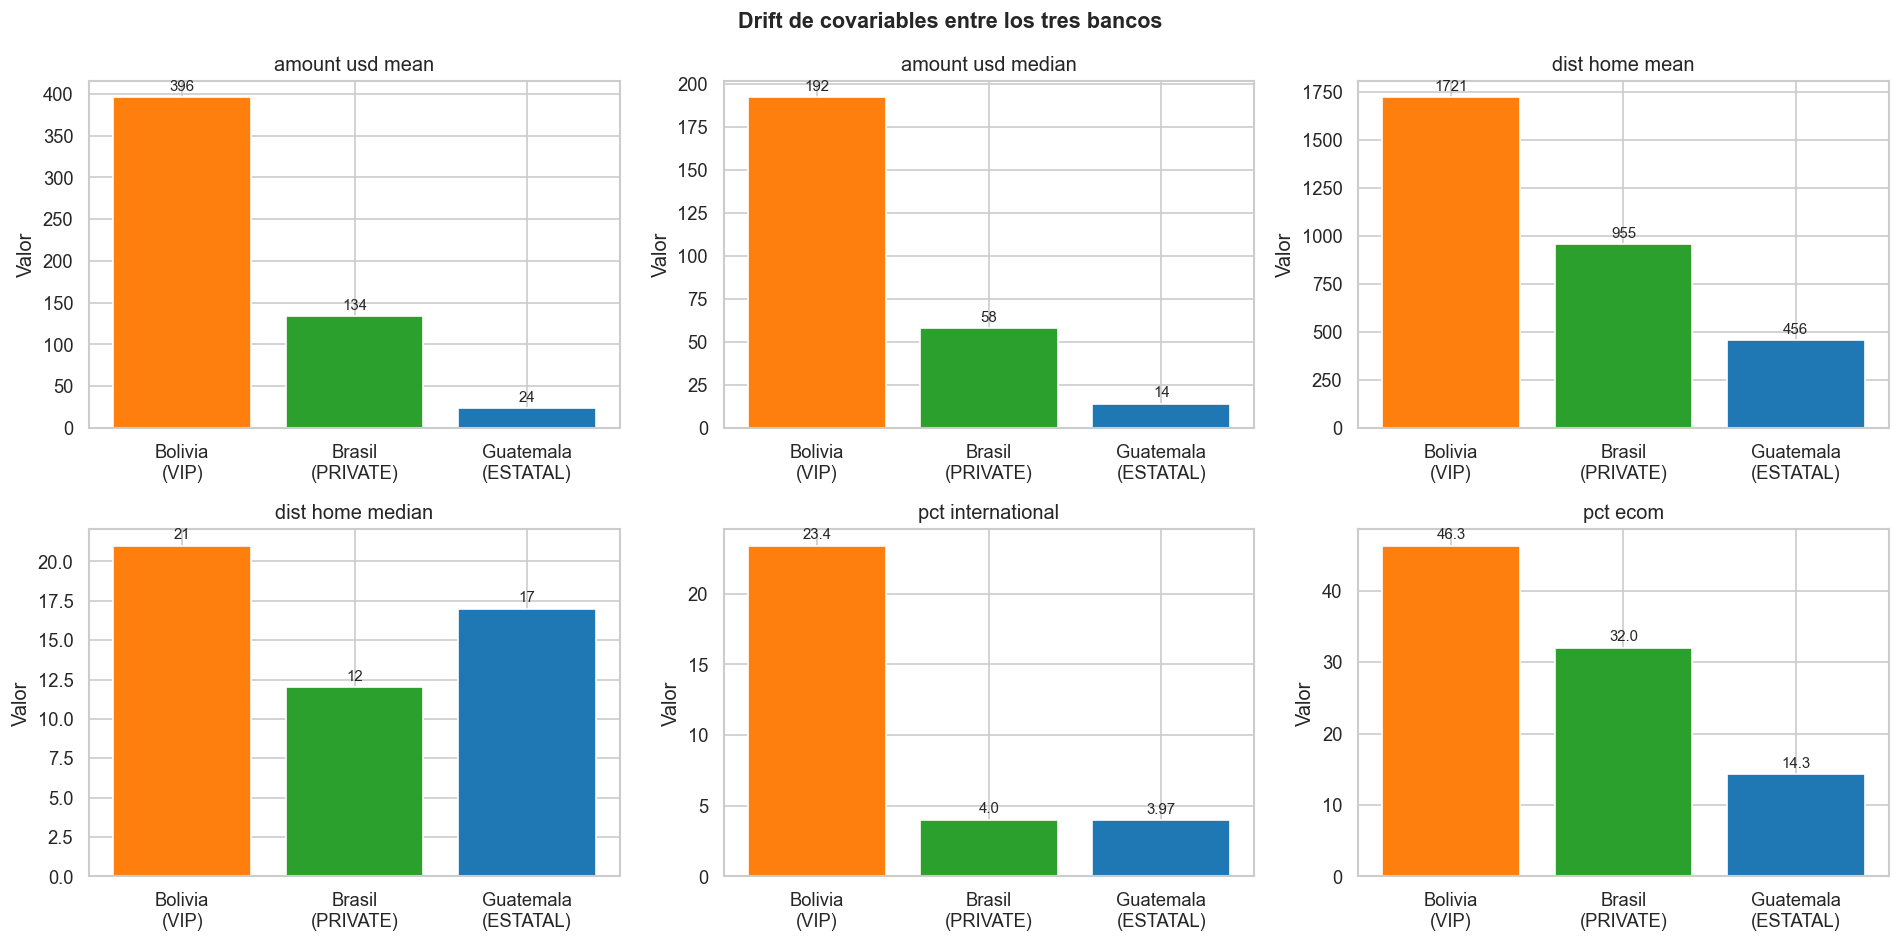

In [18]:
# Visualización del drift en variables numéricas clave
numeric_drift = {
    'amount_usd_mean':   [396, 134, 24],
    'amount_usd_median': [192, 58, 14],
    'dist_home_mean':    [1721, 955, 456],
    'dist_home_median':  [21, 12, 17],
    'pct_international': [23.4, 4.0, 3.97],   # Brasil aproximado
    'pct_ecom':          [46.3, 32.0, 14.3],
}
banks = ['Bolivia\n(VIP)', 'Brasil\n(PRIVATE)', 'Guatemala\n(ESTATAL)']
colors = ['#ff7f0e', '#2ca02c', '#1f77b4']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, (metric, values) in enumerate(numeric_drift.items()):
    axes[i].bar(banks, values, color=colors)
    axes[i].set_title(metric.replace('_', ' '))
    axes[i].set_ylabel('Valor')
    for j, v in enumerate(values):
        axes[i].text(j, v + max(values) * 0.02, str(v), ha='center', fontsize=9)

plt.suptitle('Drift de covariables entre los tres bancos', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

La tabla y los gráficos de drift confirman que Guatemala presenta una distribución de covariables
significativamente desplazada respecto a los bancos de entrenamiento:

- **Montos**: La media de `amount_usd` cae de $396 (Bolivia) a $24 (Guatemala), una reducción del 94%.
  El modelo federado no debe usar montos absolutos como features directas; deben normalizarse respecto
  al `client_baseline_amount` de cada cliente.
- **Distancia**: La media de `distance_from_home_km` cae de 1,721 km (Bolivia) a 456 km (Guatemala),
  aunque las medianas son similares (~17-21 km), indicando que la cola de transacciones lejanas es
  proporcionalmente menor en Guatemala.
- **Internacionalidad y canal ECOM**: Ambas métricas caen drásticamente en Guatemala. El modelo
  federado deberá generalizar el concepto de "transacción anómala" sin depender de que ECOM sea el
  canal mayoritario — en Guatemala, una transacción chip POS fuera del patrón habitual del cliente
  puede ser igualmente sospechosa.
- **Features agnosticas recomendadas**: `amount_zscore_customer`, `txn_count_last_1h/24h`,
  `time_since_last_txn_min` — features relativas al comportamiento histórico del cliente que son
  transferibles entre bancos independientemente del nivel absoluto de gasto.

## 10) Estrategia de inferencia para el modelo federado

In [19]:
total = len(df)
print(f'Total transacciones Guatemala: {total:,}')
print(f'Primero 30% (entregas preliminares): {int(total * 0.30):,} transacciones')
print(f'Restante 70% (entrega final)       : {int(total * 0.70):,} transacciones')
print()

# Corte temporal para el 30% inicial
if 'DE15_settlement_date' in df.columns:
    temp2 = df.copy()
    temp2['DE15_clean'] = temp2['DE15_settlement_date'].fillna(0).astype(int)
    temp2['month_parsed'] = temp2['DE15_clean'].astype(str).str.zfill(4).str[:2].astype(int)
    monthly_vol = temp2[temp2['month_parsed'].between(1,6)].groupby('month_parsed').size().reset_index(name='n')
    monthly_vol['cum_pct'] = monthly_vol['n'].cumsum() / total * 100
    print('Acumulado por mes:')
    display(monthly_vol)

Total transacciones Guatemala: 100,000
Primero 30% (entregas preliminares): 30,000 transacciones
Restante 70% (entrega final)       : 70,000 transacciones

Acumulado por mes:


,month_parsed,n,cum_pct
0,1,16418,16.418
1,2,14889,31.307
2,3,16771,48.078
3,4,16374,64.452
4,5,16609,81.061
5,6,16002,97.063


## Conclusión del EDA de Guatemala

Guatemala es el **Banco 3** del modelo federado: un banco estatal con 100,000 transacciones y **sin
etiquetas de fraude**. El EDA revela un perfil radicalmente distinto al de los bancos de entrenamiento,
con tres ejes de drift principales:

1. **Drift de montos**: `amount_usd` media de $24 vs $396 (Bolivia) — el modelo debe operar sobre
   features normalizadas por cliente, no sobre montos absolutos.
2. **Drift de canal**: POS y chip EMV dominan (56% y 57%) frente al predominio de ECOM en Bolivia (46%).
   La transaccionalidad es presencial, no digital, cambiando el patrón esperado de fraude.
3. **Drift de segmentos**: Clientela de banca masiva (PLAN_SUELDO, JUBILADO, AHORRO) vs clientela
   premium (Bolivia) o privada (Brasil), con umbrales de gasto y comportamiento habitual distintos.

A pesar del drift, el dataset comparte la misma estructura ISO 8583, el mismo período temporal y los
mismos canales transaccionales, lo que hace viable la transferencia del modelo federado. Las features
comportamentales relativas (`amount_zscore_customer`, `txn_count_last_1h`, `time_since_last_txn_min`)
son las más prometedoras para generalizar patrones de fraude entre los tres bancos, independientemente
del nivel de banca o país de operación.